In [1]:
import pandas as pd
import numpy as np
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, gca
from seaborn import heatmap
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
from Library.dslabs_functions import (plot_bar_chart,get_variable_types)

In [2]:
df_records = pd.read_excel("../DataBase/DataCollection.xlsx",sheet_name="895 Records")
df_records.shape

(895, 40)

`Distribution: Plot polymer distribution`

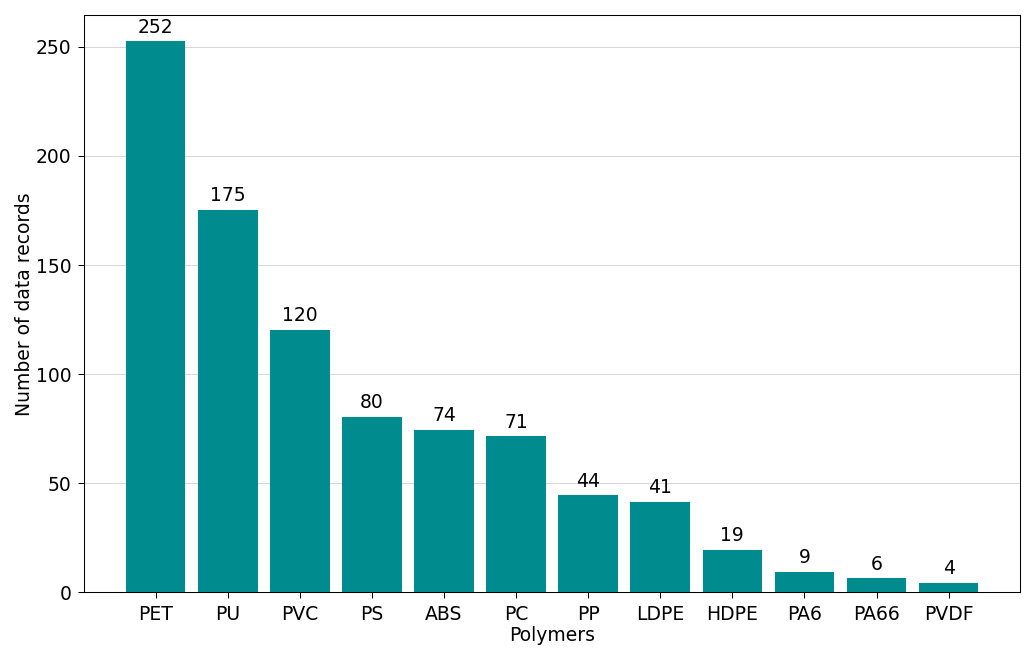

In [3]:
polymer_counts = df_records["Polymer"].value_counts()

polymer_counts_sorted = polymer_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    polymer_counts_sorted.index,
    polymer_counts_sorted.values,
    color='#008c8e',
    edgecolor='#008c8e',
    zorder=3
)

ax.set_xlabel("Polymers", fontsize=9)
ax.set_ylabel("Number of data records", fontsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=9, direction="out")

ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=0)

ymax = polymer_counts_sorted.max()
offset = 0.01 * ymax
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + offset,
        str(int(h)),
        ha='center', va='bottom',
        fontsize=9,
        color="black"
    )

plt.tight_layout()
plt.show()

`Distribution: Plot polymer distribution by dissolution outcome`

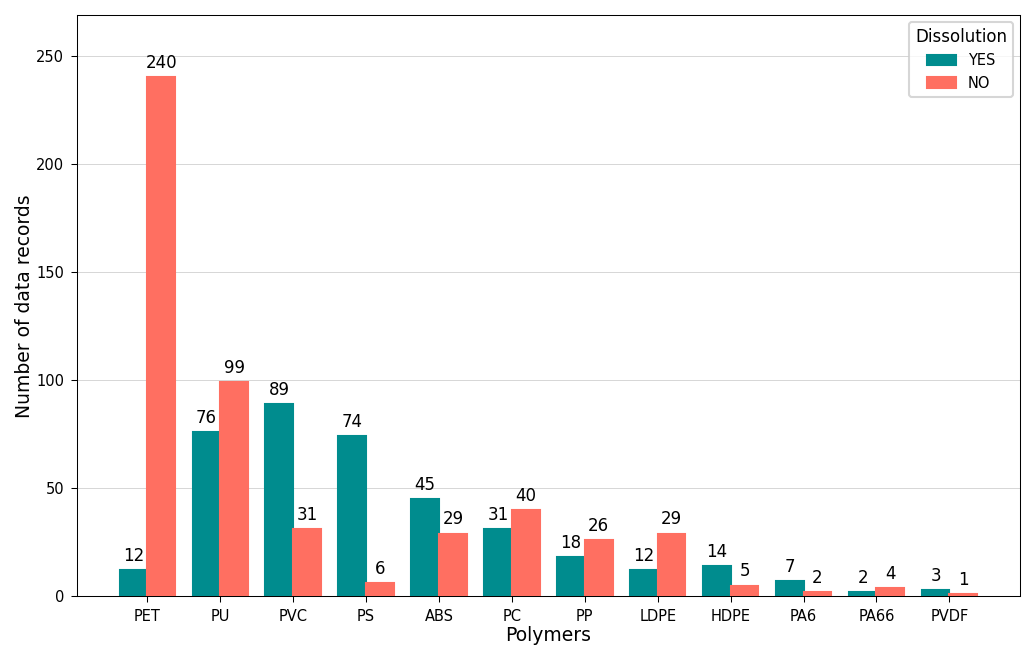

In [19]:

polymer_counts_sorted = pd.crosstab(
    df_records["Polymer"],
    df_records["Dissolution"]
)
for col in ["YES", "NO"]:
    if col not in polymer_counts_sorted.columns:
        polymer_counts_sorted[col] = 0

polymer_counts_sorted = polymer_counts_sorted[["YES", "NO"]]

polymer_counts_sorted["Total"] = polymer_counts_sorted.sum(axis=1)
polymer_counts_sorted = polymer_counts_sorted.sort_values("Total", ascending=False)
polymer_counts_sorted = polymer_counts_sorted.drop(columns="Total")

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(polymer_counts_sorted.index))
width = 0.38

bars_yes = ax.bar(
    x - width / 2,
    polymer_counts_sorted["YES"],
    width,
    label="YES",
    color="#008c8e",
    edgecolor="#008c8e",
    zorder=3
)

bars_no = ax.bar(
    x + width / 2,
    polymer_counts_sorted["NO"],
    width,
    label="NO",
    color="#ff6f61",
    edgecolor="#ff6f61",
    zorder=3
)

ax.set_xlabel("Polymers", fontsize=9)
ax.set_ylabel("Number of data records", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(polymer_counts_sorted.index)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")

ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=0)

ymax = polymer_counts_sorted.values.max()
offset = 0.01 * ymax

for bars in [bars_yes, bars_no]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + offset,
                str(int(h)),
                ha='center',
                va='bottom',
                fontsize=8,
                color="black"
            )


ax.set_ylim(0, ymax * 1.12)

ax.legend(
    title="Dissolution",
    fontsize=7,
    title_fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

`Distribution: Plot target class distribution`

Dissolution
NO     512
YES    383
Name: count, dtype: int64


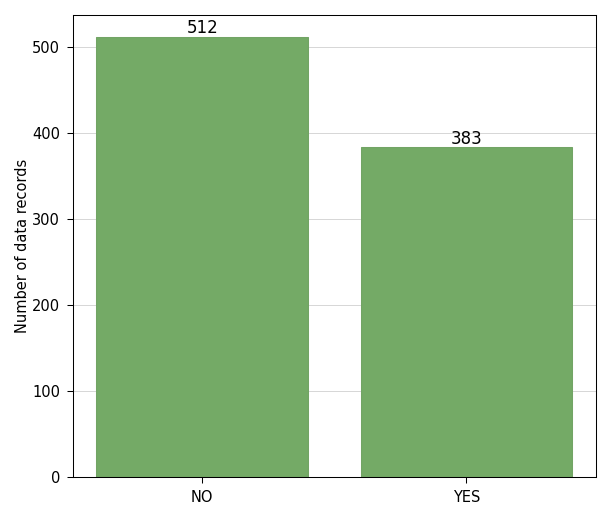

In [20]:
target = "Dissolution"

values = df_records[target].value_counts()
print(values)

figure(figsize=(4.5, 4))

plot_bar_chart(values.index.to_list(), values.to_list(), title="")

ax = gca()
ax.set_ylabel("Number of data records", fontsize=7)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")
ax.grid(axis="y", color="gray", linestyle="-", linewidth=0.3, alpha=0.5, zorder=0)

show()

`Distribution: Bar chart for Sample Type distribution`

Sample type
fiber     445
film      295
waste      88
pellet     60
powder      7
Name: count, dtype: int64


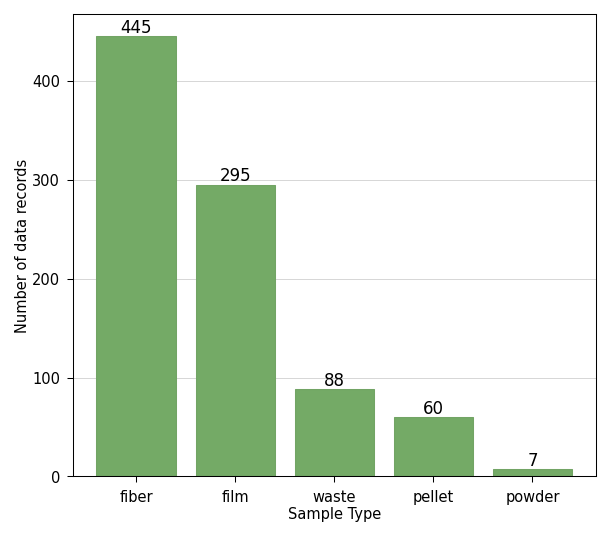

In [21]:
variable = "Sample type"

values: Series =df_records[variable].value_counts()
print(values)
figure(figsize=(4.5, 4))


plot_bar_chart(values.index.to_list(), values.to_list(), title="")

ax = gca()
ax.set_xlabel("Sample Type", fontsize=7)  
ax.set_ylabel("Number of data records", fontsize=7) 

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")

ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=0)
show()


`Correlation Analysis Heatmap`


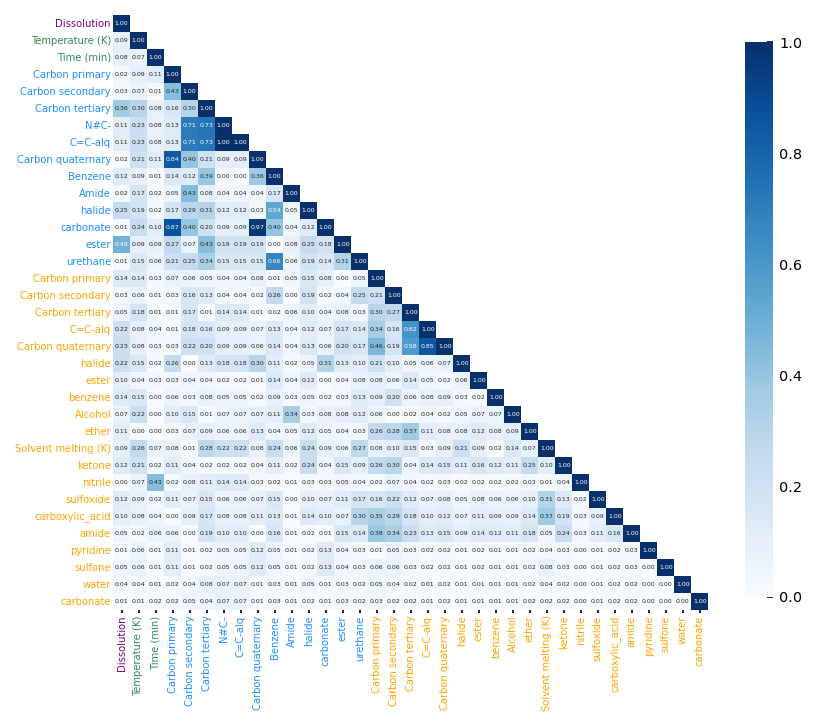

In [22]:
df_records["Dissolution"] = (
    df_records["Dissolution"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "YES": 1,
        "NO": 0
    })
)

df_records["Dissolution"] = pd.to_numeric(
    df_records["Dissolution"],
    errors="coerce"
)

variables_types: dict[str, list] = get_variable_types(df_records)

numeric: list[str] = variables_types["Numeric"]
binary: list[str] = variables_types["Binary"]

selected_vars: list[str] = numeric + binary

if "Dissolution" not in selected_vars:
    selected_vars.append("Dissolution")

selected_vars = list(dict.fromkeys(selected_vars))

selected_vars = [
    v for v in selected_vars
    if v not in ["Polymer_ID", "Solvent_ID"]
]

target_var = [
    "Dissolution"
] if "Dissolution" in selected_vars else []

time_temp_vars = [
    v for v in ["Temperature (K)", "Time (min)"]
    if v in selected_vars
]

polymer_order = [
    "Polymer_CH3",
    "Polymer_CH2",
    "Polymer_CH",
    "Polymer_N#C-",
    "Polymer_C=C-alq",
    "Polymer_C",
    "Polymer_Benzene",
    "Polymer_Amide",
    "Polymer_halide",
    "Polymer_carbonate",
    "Polymer_ester",
    "Polymer_urethane",
]

solvent_order = [
    "Solvent_CH3",
    "Solvent_CH2",
    "Solvent_CH",
    "Solvent_C=C-alq",
    "Solvent_C",
    "Solvent_halide",
    "Solvent_ester",
    "Solvent_benzene",
    "Solvent_Alcohol",
    "Solvent_ether",
    "Solvent melting (K)",
    "Solvent_ketone",
    "Solvent_nitrile",
    "Solvent_sulfoxide",
    "Solvent_carboxylic_acid",
    "Solvent_amide",
    "Solvent_pyridine",
    "Solvent_sulfone",
    "Solvent_water",
    "Solvent_carbonate",
]

polymer_vars = [
    v for v in polymer_order
    if v in selected_vars
]

solvent_vars = [
    v for v in solvent_order
    if v in selected_vars
]

other_vars = [
    v for v in selected_vars
    if v not in target_var + time_temp_vars + polymer_vars + solvent_vars
]

ordered_vars = (
    target_var
    + time_temp_vars
    + polymer_vars
    + solvent_vars
    + other_vars
)


corr_mtx: DataFrame = df_records[ordered_vars].corr(method="pearson").abs()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool),k=1)

def clean_label(label: str) -> str:
    rename_map = {
        # Polymer
        "Polymer_CH3": "Carbon primary",
        "Polymer_CH2": "Carbon secondary",
        "Polymer_CH": "Carbon tertiary",
        "Polymer_C": "Carbon quaternary",
        "Polymer_N#C-": "N#C-",
        "Polymer_C=C-alq": "C=C-alq",
        "Polymer_Benzene": "Benzene",
        "Polymer_Amide": "Amide",
        "Polymer_halide": "halide",
        "Polymer_carbonate": "carbonate",
        "Polymer_ester": "ester",
        "Polymer_urethane": "urethane",

        # Solvent
        "Solvent_CH3": "Carbon primary",
        "Solvent_CH2": "Carbon secondary",
        "Solvent_CH": "Carbon tertiary",
        "Solvent_C": "Carbon quaternary",
        "Solvent_C=C-alq": "C=C-alq",
        "Solvent_halide": "halide",
        "Solvent_ester": "ester",
        "Solvent_benzene": "benzene",
        "Solvent_Alcohol": "Alcohol",
        "Solvent_ether": "ether",
        "Solvent_ketone": "ketone",
        "Solvent_nitrile": "nitrile",
        "Solvent_sulfoxide": "sulfoxide",
        "Solvent_carboxylic_acid": "carboxylic_acid",
        "Solvent_amide": "amide",
        "Solvent_pyridine": "pyridine",
        "Solvent_sulfone": "sulfone",
        "Solvent_water": "water",
        "Solvent_carbonate": "carbonate",
    }

    return rename_map.get(label, label)

display_labels = [
    clean_label(v)
    for v in ordered_vars
]

def get_label_color(label: str) -> str:
    if label == "Dissolution":
        return "purple"

    elif label in ["Temperature (K)", "Time (min)"]:
        return "seagreen"

    elif label.startswith("Polymer_"):
        return "dodgerblue"

    elif label.startswith("Solvent_") or label == "Solvent melting (K)":
        return "orange"

    else:
        return "black"


figure(figsize=(6.4, 6.4))

heatmap(
    corr_mtx,
    mask=mask,
    xticklabels=display_labels,
    yticklabels=display_labels,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot_kws={"size": 3},
    cbar_kws={"shrink": 0.75, "anchor": (0.0, 0.5)},
    linewidths=0,
    linecolor="white",
    square=True
)

ax = gca()

cbar = ax.collections[0].colorbar
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0, 0.15, pos.width, 0.825])

ax.set_aspect("equal")
ax.set_anchor("NW")

ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=4.8,
    pad=1
)

ax.tick_params(
    axis="y",
    labelsize=4.8,
    pad=1
)

for tick_label, original_name in zip(ax.get_xticklabels(), ordered_vars):
    tick_label.set_color(get_label_color(original_name))
    tick_label.set_fontweight("normal")
    tick_label.set_fontsize(4.8)

for tick_label, original_name in zip(ax.get_yticklabels(), ordered_vars):
    tick_label.set_color(get_label_color(original_name))
    tick_label.set_fontweight("normal")
    tick_label.set_fontsize(4.8)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)
    
show()